# Домашнее задание: Кластеризация текстов

Сеть супермаркетов «Перекрёсток» собирает отзывы от клиентов по разным каналам: мобильное приложение, сайт, чековые анкеты. Отзывы включают как положительные оценки, так и жалобы — на персонал, доставку, свежесть товаров, наличие и т.д.

**Бизнес сталкивается с проблемой**:

* Отзывов слишком много, они разнообразны по формулировкам.
* Ручная обработка отзывов — долгая и неэффективная.
* Нельзя быстро понять, о чём говорят клиенты, какие темы повторяются.

**Цель бизнеса**:

* Автоматически группировать отзывы по смыслу, чтобы:
* обнаруживать повторяющиеся проблемы (например, "не тот товар", "просрочка"),
* оценивать работу конкретных магазинов и доставок,
* поддерживать продуктовые и операционные улучшения на основе обратной связи.



In [ ]:
!pip freeze > start_env.txt

# Читаем данные

Скачаем данные по отзывам на продукты. Предобработаем их и отфильтруем небольшое количество, чтобы потрогать руками различные алгоритмы, рассмотренные на лекции.

Для упрощения анализа кластеров и возможности здраво оценить, насколько результаты приемлемы, разделим данные на две явно разделенные по смыслу (во всяком случае, в среднем) группы: отзывы с максимальной оценкой и отзывы с минимальной оценкой.

In [ ]:
# помогает с ошибкой чтения датасета с HF
!pip install fsspec==2023.6.0

In [1]:
from datasets import load_dataset

# Загружаем train-часть датасета
dataset = load_dataset("lapki/perekrestok-reviews", split="train")
print(dataset)

README.md:   0%|          | 0.00/709 [00:00<?, ?B/s]

perekrestok.jsonl:   0%|          | 0.00/606M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/642682 [00:00<?, ? examples/s]

Dataset({
    features: ['product_id', 'product_name', 'product_category', 'product_price', 'review_id', 'review_author', 'review_text', 'rating'],
    num_rows: 642682
})


In [2]:
from datasets import load_dataset
import pandas as pd

N = 10000
df = dataset.to_pandas()
df = df[["review_id", "product_category", "product_name", "review_text", "rating"]]
df = df.sort_values(by="review_id").head(N)
df.head(2)


,review_id,product_category,product_name,review_text,rating
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0


In [3]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Применяем очистку
df["clean_text"] = df["review_text"].apply(clean_text)
df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0,самые лучшие соки. всегда беру детям только их...
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0,"вкуснее, чем у известных конкурентов."


In [4]:
neg = df[df["rating"] == 1.0].sort_values(by="review_id")[:500]
pos = df[df["rating"] == 5.0].sort_values(by="review_id")[:500]
cut_df = pd.concat([neg, pos]).reset_index(drop=True)
cut_df["rating"].value_counts()

rating
1.0    500
5.0    500
Name: count, dtype: int64

In [5]:
cut_df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
0,3972,"Чай, кофе, сахар",Сахар песок белый 1кг,запекала сахар вместе с дыней. дыня совсем не ...,1.0,запекала сахар вместе с дыней. дыня совсем не ...
1,4462,"Чай, кофе, сахар",Кофе молотый Julius Meinl Prasident 250г,Почти без запаха.,1.0,почти без запаха.


# Алгоритмы визуализации - 5 баллов

Реализуйте функции для сжатия эмбеддингов до двумерного пространства с помощью подходов t-SNE и UMAP. Каждая функция должна строить изображения поданных на вход эмбеддингов в пространстве, а также учитывать, какое расстояние между эмбеддингами мы считаем (евклидово или косинусное).

Протестируйте их на небольшом семпле.

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import umap


# Можно реализовать через одну функцию, но для тестирования разных сетапов было удобно делать две отдельно

# Визуализация через t-SNE
def plot_embeddings(embeds, title, metric="euclidean", labels=None, cosine_via_l2=False):    # в прошлом уроке удобно было красить через labels
    # ---- Ваш код здесь ----
    print("строим tsne")
    embeds = np.asarray(embeds, dtype=np.float64)
    n_samples = embeds.shape[0]

    # на нескольких запусках заметил, что t-sne может не сходиться, особенно для косинусной метрики на мелком датасете
    # переведем в евклидову метрику, тогда результат будет стабильнее, а смысл сохранится

    # не знаю, насколько правомерен такой подход, потом посмотрим по смыслу заданий.
    # По умолчанию - отключено! Считаем честный косинус, но иногда не сходится.

    # Для косинусной метрики есть два варианта:
    #   cosine_via_l2=True  — L2-нормализуем векторы и используем евклидову метрику.
    #     На нормализованных ||a-b||^2 = 2(1 - cos(a,b)) — монотонно связано с
    #     косинусным. Позволяет init="pca" (детерминирован) → стабильнее.
    #   cosine_via_l2=False — передаём metric="cosine" напрямую в TSNE.
    #     Инициализация принудительно "random" (PCA несовместим с не-евклидом),
    #     результат может сильнее "разбегаться" от запуска к запуску.
    if metric == "cosine" and cosine_via_l2:
        norms = np.linalg.norm(embeds, axis=1, keepdims=True)
        embeds_in = embeds / np.clip(norms, 1e-12, None)
        tsne_metric = "euclidean"
        tsne_init = "pca"
    elif metric == "cosine":
        embeds_in = embeds
        tsne_metric = "cosine"
        tsne_init = "random"
    else:
        embeds_in = embeds
        tsne_metric = metric
        tsne_init = "pca"

    # perplexity должна быть < n_samples; на больших N разумно ~N/30, ограничено [5, 50]
    perplexity = min(50, max(5, n_samples // 30))
    perplexity = min(perplexity, n_samples - 1)

    # Для маленьких выборок точный метод стабильнее, чем Barnes-Hut
    method = "exact" if n_samples < 100 else "barnes_hut"

    tsne = TSNE(
        n_components=2,
        metric=tsne_metric,
        perplexity=perplexity,
        init=tsne_init,
        method=method,
        random_state=42,
    )
    coords = tsne.fit_transform(embeds_in)

    plt.figure(figsize=(6, 4))
    if labels is None:
        plt.scatter(coords[:, 0], coords[:, 1], s=20, alpha=0.8)
    else:
        labels = np.asarray(labels)
        for cls in np.unique(labels):
            mask = labels == cls
            plt.scatter(coords[mask, 0], coords[mask, 1], s=20, alpha=0.8, label=str(cls))
        plt.legend()
    metric_label = f"{metric} via L2+euclidean" if metric == "cosine" and cosine_via_l2 else metric
    plt.title(f"{title} (t-SNE, {metric_label})")
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.grid(True, alpha=0.3)
    # ---- Конец кода ----


    plt.show()


# Визуализация через UMAP
def plot_embeddings_umap(embeds, title, metric="euclidean", labels=None): # так же добавим labels для красоты
    # ---- Ваш код здесь ----
    print("строим umap")
    embeds = np.asarray(embeds)
    n_samples = embeds.shape[0]
    n_neighbors = min(15, max(2, n_samples - 1))

    reducer = umap.UMAP(
        n_components=2,
        metric=metric,
        n_neighbors=n_neighbors,
        random_state=42,
    )
    coords = reducer.fit_transform(embeds)

    plt.figure(figsize=(6, 4))
    if labels is None:
        plt.scatter(coords[:, 0], coords[:, 1], s=20, alpha=0.8)
    else:
        labels = np.asarray(labels)
        for cls in np.unique(labels):
            mask = labels == cls
            plt.scatter(coords[mask, 0], coords[mask, 1], s=20, alpha=0.8, label=str(cls))
        plt.legend()
    plt.title(f"{title} (UMAP, {metric})")
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.grid(True, alpha=0.3)
    # ---- Конец кода ----


    plt.show()

строим tsne


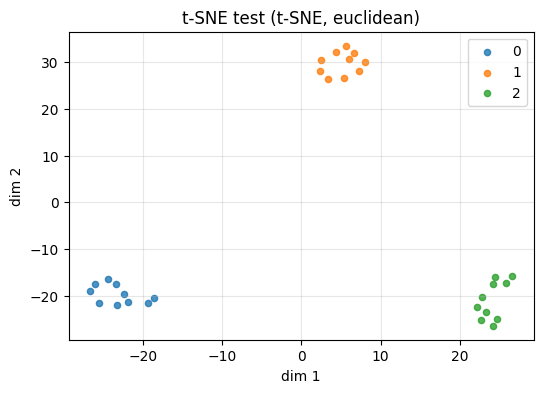

строим tsne


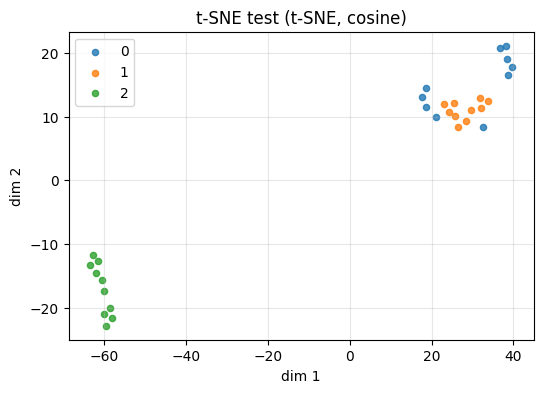

строим umap


c:\igori\pytorch\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


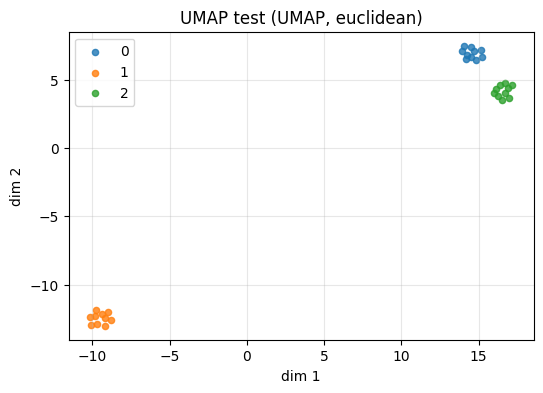

строим umap


c:\igori\pytorch\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


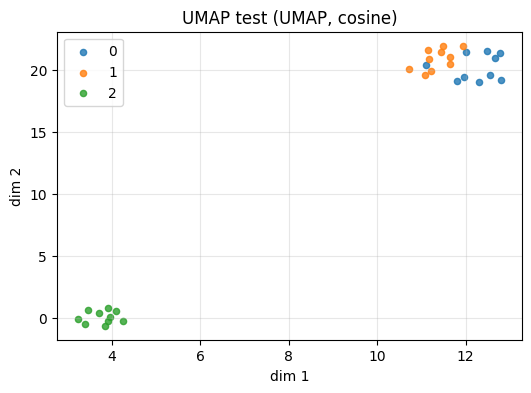

In [27]:
embs = np.concatenate([np.random.rand(10, 3), np.random.rand(10, 3) + 2, np.random.rand(10, 3) - 1], axis=0)
# добавим искусственные метки для красоты
test_labels = np.array([0] * 10 + [1] * 10 + [2] * 10)

plot_embeddings(embs, "t-SNE test", metric="euclidean", labels=test_labels)
plot_embeddings(embs, "t-SNE test", metric="cosine", labels=test_labels)
plot_embeddings_umap(embs, "UMAP test", metric="euclidean", labels=test_labels)
plot_embeddings_umap(embs, "UMAP test", metric="cosine", labels=test_labels)


# Зависимость кластеров от эмбеддера - 5 баллов

В данной части предлагается оценить, насколько эмбеддер на качество кластеризации может влиять:
а) эмбеддер
б) выбранная метрика расстояния

Возьмите следующие две модели:
1) "ai-forever/FRIDA" -- хороший качественный эмбеддер
2) "cointegrated/rubert-tiny2" -- достаточно слабый по современным меркам эмбеддер

Реализуйте подгрузку этой модели через класс SentenceTransformer и постройте визуализацию кластеров
а) через функцию с UMAP и через функцию с t-SNE
б) и для каждого варианта -- визуализацию с евклидовым расстоянием и с косинусным расстоянием
в) и для каждого варианта -- с эмбеддером FRIDA и с эмбеддером rubert-tiny2

Итого должно получиться 8 графиков. Сделайте выводы, какой эмбеддер визуально разграничивает данные лучше.

загружаем две модели и считаем эмбеддинги для каждой от texts, а затем рисуем графики функциями выше


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

строим tsne


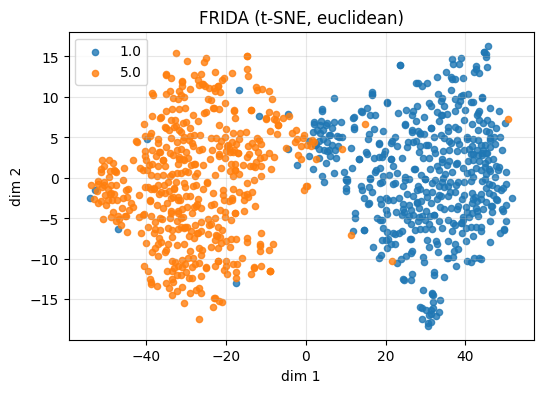

строим tsne


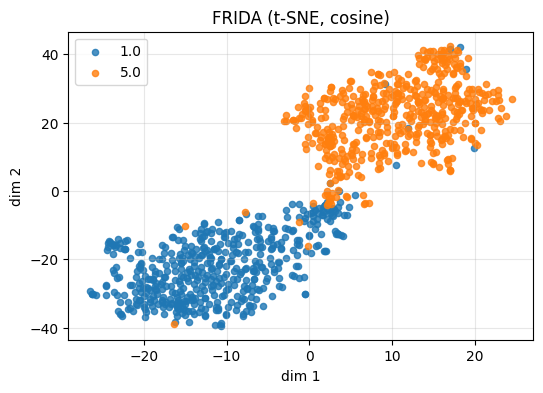

строим umap


c:\igori\pytorch\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


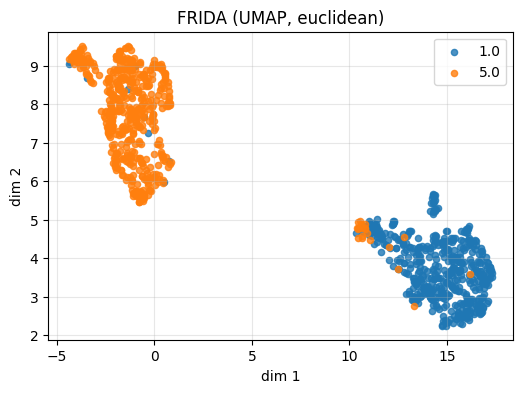

строим umap


c:\igori\pytorch\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


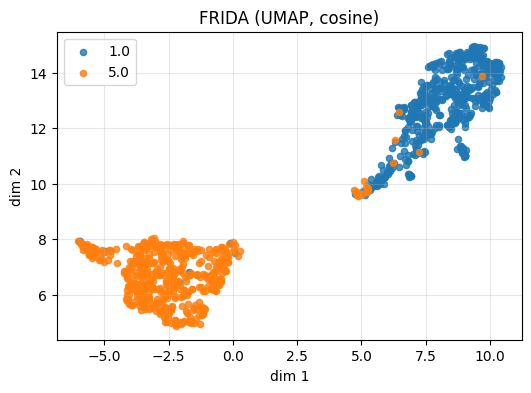

строим tsne


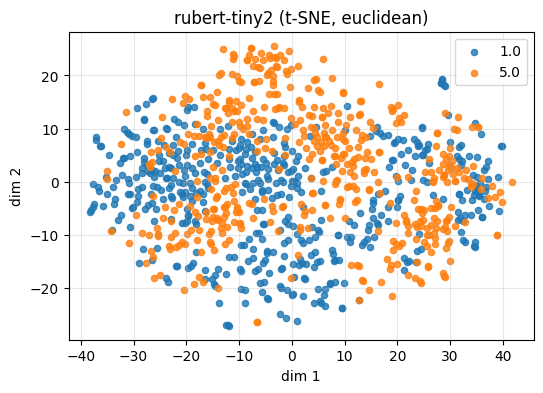

строим tsne


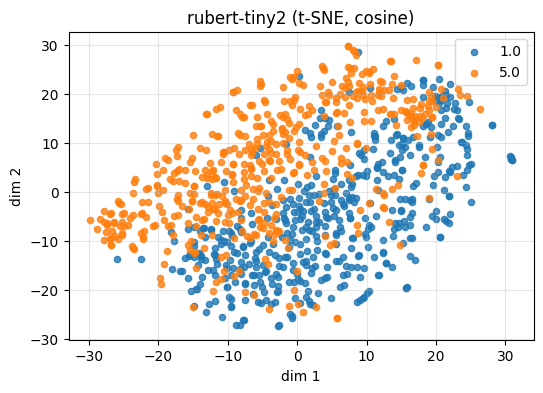

строим umap


c:\igori\pytorch\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


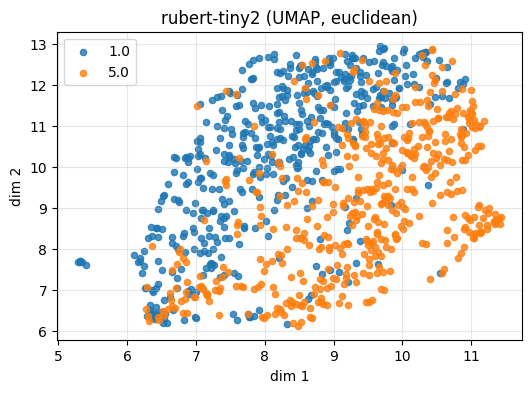

строим umap


c:\igori\pytorch\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


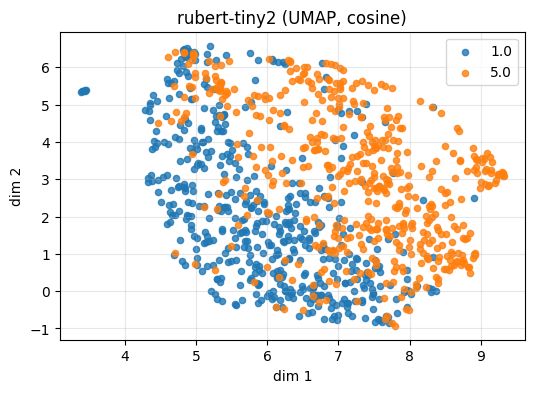

Визуально FRIDA конечно сольнее руберта, но и размер в 4 раза больше.
А вообще надо смотреть на задачах после тренировки головы, во второй домашке это было так.


In [ ]:
from sentence_transformers import SentenceTransformer

texts = cut_df["clean_text"].values

# ---- Ваш код здесь ----
# сразу и лэйблы раскрасим
rating_labels = cut_df["rating"].values  # 1.0 = neg, 5.0 = pos

print("загружаем две модели и считаем эмбеддинги для каждой от texts, а затем рисуем графики функциями выше")
# FRIDA 0,8B — большой эмбеддер на FRED-T5, обучен с системой префиксов под задачи.
# Для кластеризации позитив/негатив наиболее релевантный префикс —
# "categorize_sentiment:" (см. карточку модели).
model_frida = SentenceTransformer("ai-forever/FRIDA")
frida_inputs = ["categorize_sentiment: " + t for t in texts]
embs_frida = model_frida.encode(
    frida_inputs, batch_size=16, show_progress_bar=True, convert_to_numpy=True
)

# rubert-tiny2 — компактный BERT для русского, без префиксов
model_tiny = SentenceTransformer("cointegrated/rubert-tiny2")
embs_tiny = model_tiny.encode(
    list(texts), batch_size=64, show_progress_bar=True, convert_to_numpy=True
)

# По 4 графика на модель: {t-SNE, UMAP} × {euclidean, cosine}
for name, embs in [("FRIDA", embs_frida), ("rubert-tiny2", embs_tiny)]:
    plot_embeddings(embs, name, metric="euclidean", labels=rating_labels)
    plot_embeddings(embs, name, metric="cosine", labels=rating_labels)
    plot_embeddings_umap(embs, name, metric="euclidean", labels=rating_labels)
    plot_embeddings_umap(embs, name, metric="cosine", labels=rating_labels)

print("Визуально FRIDA конечно сильнее руберта, но и размер в 4 раза больше.\n" \
"А вообще надо смотреть на задачах после тренировки головы, во второй домашке это было так.")
# ---- Конец кода ----



# Зависимость кластеров от алгоритма кластеризации - 10 баллов

Реализуйте кластеризацию выбранных нами текстов через алгоритмы KMeans, MiniBatchKMeans, HDBSCAN. Сравните эти алгоритмов визуально и по метрикам. В качестве метрик используйте silhouette_score для безотносительной оценки качества и adjusted_rand_score для оценки качества относительно рейтинга (1.0 или 5.0). Визуализацию делайте с помощью UMAP.

compare_clusterers принимает на вход кластеризуемые эмбеддинги и, опционально, референсные значения кластеров (в нашем случае -- принадлежность к рейтингу). Функция должна отрисовывать кластера в пространстве для трех алгоритмов и возвращать метрики по каждому из них в виде словаря.

In [47]:
from sklearn.cluster import KMeans, MiniBatchKMeans
try:
    from sklearn.cluster import HDBSCAN  # sklearn >= 1.3
except ImportError:
    from hdbscan import HDBSCAN  # fallback: pip install hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


def compare_clusterers(embeddings, true_labels=None, n_clusters=5):
    results = {}


    # ---- Ваш код здесь ----
    print("кластеризуем и тремя моделями и считаем метрики силуэт и ari")
    embeddings = np.asarray(embeddings)
    true_labels_arr = np.asarray(true_labels) if true_labels is not None else None

    clusterers = {
        "KMeans": KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
        "MiniBatchKMeans": MiniBatchKMeans(
            n_clusters=n_clusters, random_state=42, n_init=10, batch_size=256
        ),
        # HDBSCAN — density-based, сам решает число кластеров; min_cluster_size
        # задаёт минимальный размер плотной области (для 1000 точек ~30 разумно)
        "HDBSCAN": HDBSCAN(
            min_cluster_size=30
        ),
    }

    # Общая UMAP-проекция для всех трёх алгоритмов — чтобы графики были
    # сопоставимы (кластера ищем в исходном пространстве, рисуем в одном 2D)
    reducer = umap.UMAP(n_components=2, n_neighbors=15, metric="cosine", random_state=42)
    coords = reducer.fit_transform(embeddings)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (name, clf) in zip(axes, clusterers.items()):
        pred = clf.fit_predict(embeddings)
        unique = np.unique(pred)
        n_found = int(len(unique) - (1 if -1 in unique else 0))

        # silhouette: нужно >= 2 кластеров и не все точки в одном.
        # Для HDBSCAN шумовые точки (-1) исключаем из расчёта.
        sil = None
        if -1 in unique:
            mask = pred != -1
            if mask.sum() > 1 and len(np.unique(pred[mask])) >= 2:
                sil = float(silhouette_score(embeddings[mask], pred[mask]))
        elif len(unique) >= 2:
            sil = float(silhouette_score(embeddings, pred))

        ari = None
        if true_labels_arr is not None:
            ari = float(adjusted_rand_score(true_labels_arr, pred))

        results[name] = {"silhouette": sil, "ari": ari, "n_clusters_found": n_found}

        # Визуализация: шум HDBSCAN — серым, остальные цвета per-cluster
        for cls in unique:
            m = pred == cls
            if cls == -1:
                ax.scatter(coords[m, 0], coords[m, 1], s=10, alpha=0.3,
                           c="lightgray", label="noise")
            else:
                ax.scatter(coords[m, 0], coords[m, 1], s=10, alpha=0.8,
                           label=f"c{cls}")

        title_parts = [f"{name} (k={n_found})"]
        if sil is not None:
            title_parts.append(f"sil={sil:.3f}")
        if ari is not None:
            title_parts.append(f"ARI={ari:.3f}")
        ax.set_title(" | ".join(title_parts))
        ax.legend(fontsize=7, markerscale=1.5, loc="best")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # ---- Конец кода ----

    plt.show()

    return results

кластеризуем и тремя моделями и считаем метрики силуэт и ari


c:\igori\pytorch\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


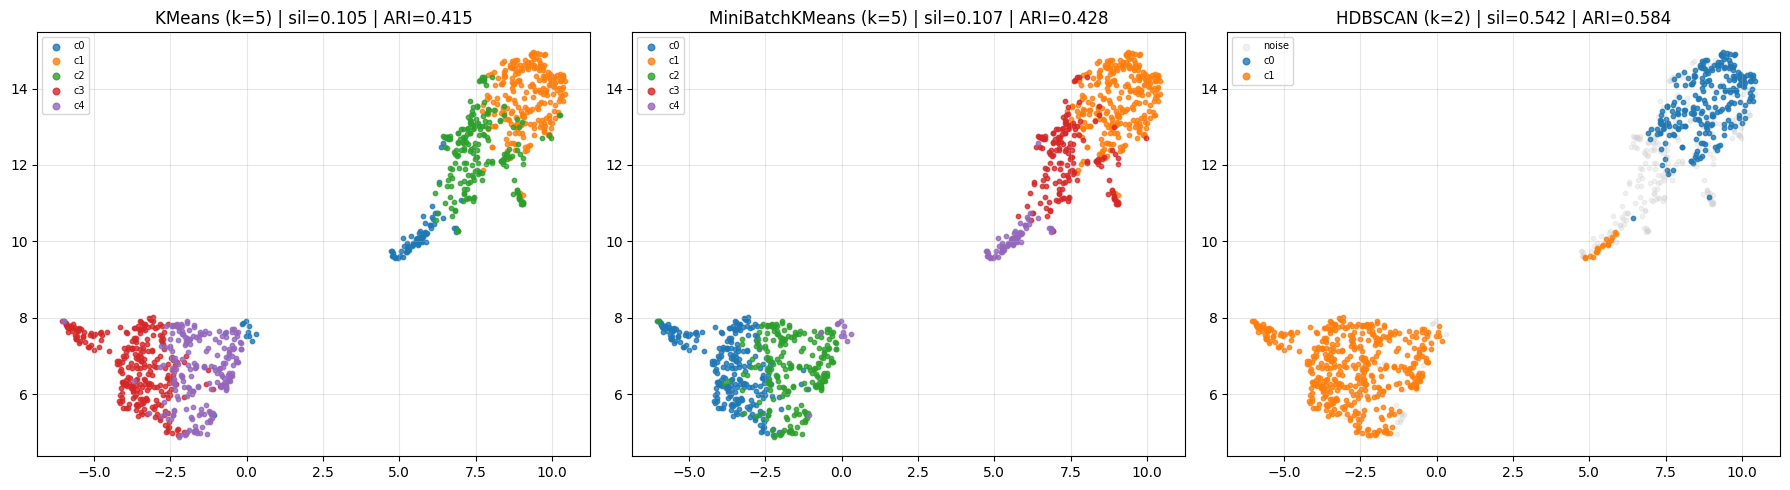

То же самое, но с 2 кластерами для KMeans и MiniBatchKMeans, а HDBSCAN пусть сам решает
кластеризуем и тремя моделями и считаем метрики силуэт и ari


c:\igori\pytorch\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


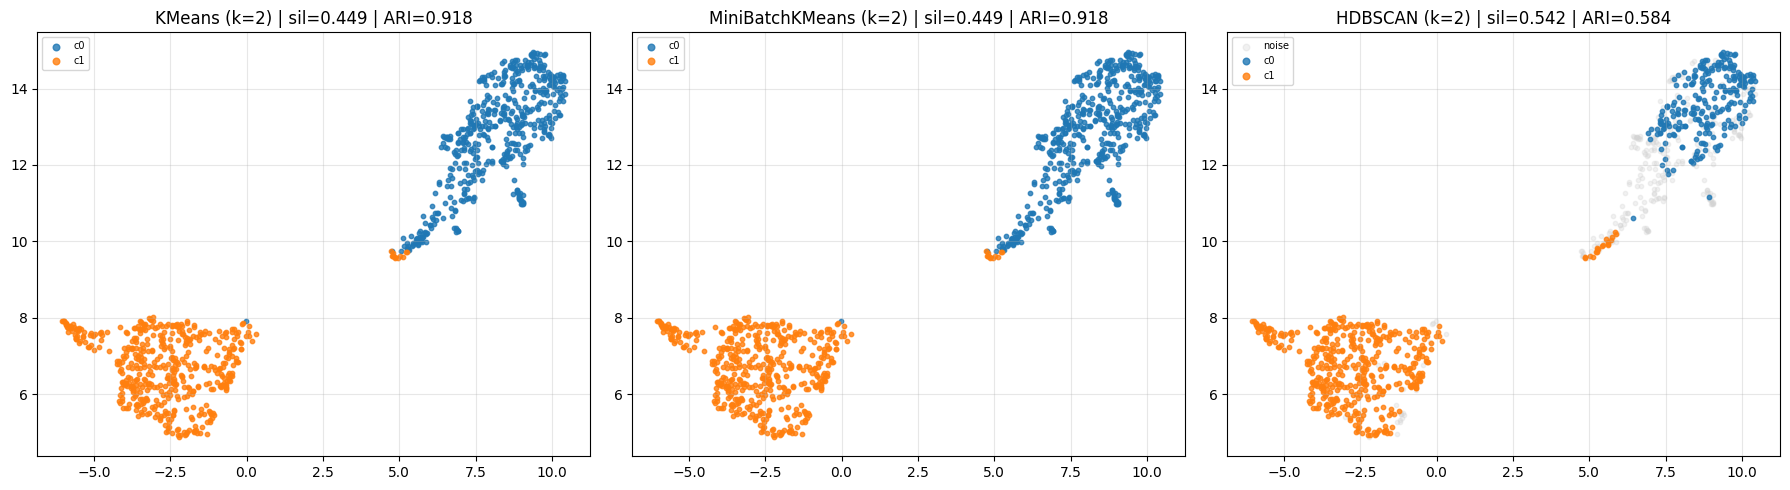

{'KMeans': {'silhouette': 0.4490377604961395,
  'ari': 0.9176815995283303,
  'n_clusters_found': 2},
 'MiniBatchKMeans': {'silhouette': 0.4490377604961395,
  'ari': 0.9176815995283303,
  'n_clusters_found': 2},
 'HDBSCAN': {'silhouette': 0.541764497756958,
  'ari': 0.5841396600531512,
  'n_clusters_found': 2}}

In [48]:
# embeddings: np.array, shape = (n_samples, embedding_dim)
# true_labels: list или np.array (опционально)

good_embeds = embs_frida  # выберем лучшие эмбеддинги для кластеризации
# good_embeds = embs_tiny  # но посмотрим на обеих. Посмотрел - вообще всё плохо. ARI вообще по нулям.

true_labels = (cut_df["rating"] == 5.0).apply(int)
# а лэйблы мы ранее посчитали
# вот накойхер тут 5 кластеров? Мыж датасет поделили на два класса
results = compare_clusterers(good_embeds, true_labels=rating_labels, n_clusters=5)

print("То же самое, но с 2 кластерами для KMeans и MiniBatchKMeans, а HDBSCAN пусть сам решает")

results = compare_clusterers(good_embeds, true_labels=rating_labels, n_clusters=2)
results

# Интерпретируемость кластеров

## BERTopic - 5 баллов

Попробуем построить интерпретацию получаемых кластеров с помощью BERTopic, реализованного в виде отдельного фреймворка (строит кластера, считает c-TF-IDF, отбирает самые частотные и характеризующие кластер слова).

Если считать частотные слова напрямую, то в топе окажется много служебные слов, которые называют "стоп-словами". Игнорируйте эти слова при построении BERTopic -- это можно сделать с помощью переопределения vectorizer_model, заменив его на sklearn.CountVectorizer с использованием nltk stopwords.

In [ ]:
!pip install -q bertopic

In [ ]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

# import plotly.io as pio
# pio.renderers.default = "notebook_connected"

from plotly.io import renderers
# renderers.default = "notebook_connected" # интерактив в Jupyter/Colab
renderers.default = "vscode"


In [ ]:

# ---- Ваш код здесь ----
print("стоп-слова и векторайзер")
# NLTK stopwords для русского — убираем служебные слова перед c-TF-IDF,
# иначе в топах будут "не", "и", "в", "на" и т.п.
nltk.download("stopwords", quiet=True)
russian_stopwords = stopwords.words("russian")
# Доменно-специфичные "наполнители" из отзывов, которых нет в NLTK
extra_stopwords = ["это", "просто", "тоже", "всё", "все", "ещё", "еще", "вообще"]
russian_stopwords = list(set(russian_stopwords + extra_stopwords))

# CountVectorizer с русскими стоп-словами; unigrams + bigrams для более
# содержательных ключевых фраз ("не свежий", "очень вкусно" и т.п.)
vectorizer_model = CountVectorizer(
    stop_words=russian_stopwords,
    ngram_range=(1, 2),
    min_df=2,    # игнорируем слова, встретившиеся в одном документе
)

embedding_model = model_frida  # используем FRIDA — лучше всех разделяла данные
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="russian",
    calculate_probabilities=True,
    verbose=False,
)

# ---- Конец кода ----

стоп-слова и векторайзер


In [61]:
# ---- Ваш код здесь ----
print("вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова")
# Передаём уже посчитанные эмбеддинги, чтобы BERTopic не пересчитывал их заново
topics, probs = topic_model.fit_transform(list(texts), embs_frida)

# Сводная таблица по найденным топикам
df_topics = topic_model.get_topic_info()
print(df_topics)

# Топовые слова для каждого кластера (кроме -1 = outliers)
for topic_id in df_topics["Topic"]:
    if topic_id == -1:
        continue
    top_words = topic_model.get_topic(topic_id)
    words_str = ", ".join(w for w, _ in top_words[:10])
    print(f"Topic {topic_id}: {words_str}")

# Интерактивные визуализации: распределение топиков в 2D и баркчарты слов
topic_model.visualize_topics().show()
topic_model.visualize_barchart(top_n_topics=min(8, len(df_topics) - 1), n_words=10).show()

# ---- Конец кода ----


df_topics.head()

вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова
   Topic  Count                             Name  \
0      0    511    0_очень_вкус_запах_невозможно   
1      1    435  1_очень_вкусный_спасибо_хороший   
2      2     54     2_очень_именно_беру_отличные   

                                      Representation  \
0  [очень, вкус, запах, невозможно, пришлось, буд...   
1  [очень, вкусный, спасибо, хороший, вкус, вкусн...   
2  [очень, именно, беру, отличные, состав, мукой,...   

                                 Representative_Docs  
0  [попалось очень странная, всегда брал, а тепер...  
1  [всегда берём только окские - очень вкусные!, ...  
2  [очень вкусный хлеб, похож на шведский. в план...  
Topic 0: очень, вкус, запах, невозможно, пришлось, буду, купила, рекомендую, покупать, качество
Topic 1: очень, вкусный, спасибо, хороший, вкус, вкусные, средство, рекомендую, вкусная, отличный
Topic 2: очень, именно, беру, отличные, состав, мукой, пр

,Topic,Count,Name,Representation,Representative_Docs
0,0,511,0_очень_вкус_запах_невозможно,"[очень, вкус, запах, невозможно, пришлось, буд...","[попалось очень странная, всегда брал, а тепер..."
1,1,435,1_очень_вкусный_спасибо_хороший,"[очень, вкусный, спасибо, хороший, вкус, вкусн...","[всегда берём только окские - очень вкусные!, ..."
2,2,54,2_очень_именно_беру_отличные,"[очень, именно, беру, отличные, состав, мукой,...","[очень вкусный хлеб, похож на шведский. в план..."


## Интерпретация через LLM - 15 баллов

Реализуйте интерпретацию кластеров с помощью LLM: кластеризуйте данные с помощью HDBSCAN, удалите аномалии (кластер -1), затем для каждого кластера насемплируйте 5-10 примеров.

Возьмите любую адекватную для русского языка LLM (например, saiga-yandexgpt из первой дз, либо для скорости можно взять qwen-2-0.5b -- хотя по качеству она будет достаточно слабой), и напишите к ней промпт, по которому данная ллм на основе семплированных отзывов должна написать короткое описание кластера.

В качестве результата выведите датафрейм, в котором для каждого кластера будет номер кластера, короткое описание кластера и использованный семпл.

In [65]:
# чистим cuda память
import gc

import torch
torch.cuda.empty_cache()
gc.collect()

0

In [67]:
import pandas as pd
import numpy as np
import random
from sentence_transformers import SentenceTransformer
from sklearn.cluster import HDBSCAN
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics.pairwise import cosine_distances
pd.set_option("display.max_colwidth", None)

from openai import OpenAI
from rich import print as rprint

# ---- Ваш код здесь ----
print("реализуем семлпирование и разметку")
# Кластеризация HDBSCAN на FRIDA-эмбеддингах (они лучше разделяли данные).
# min_samples снижен до 5 — меньше точек уйдёт в "шум" (-1)
hdbscan = HDBSCAN(min_cluster_size=30, min_samples=5)
cluster_labels = hdbscan.fit_predict(embs_frida)

# Удаляем аномалии (cluster == -1)
valid_cluster_ids = sorted(c for c in np.unique(cluster_labels) if c != -1)
print(f"Найдено кластеров: {len(valid_cluster_ids)} "
      f"(шумовых точек: {(cluster_labels == -1).sum()} из {len(cluster_labels)})")

# Семпл 5-10 отзывов на кластер
SAMPLES_PER_CLUSTER = 8 # choosen by fair dice roll - guaranteed to be random
rng = np.random.default_rng(42)

cluster_samples = {}
for cid in valid_cluster_ids:
    idxs = np.where(cluster_labels == cid)[0]
    take = min(SAMPLES_PER_CLUSTER, len(idxs))
    chosen = rng.choice(idxs, size=take, replace=False)
    cluster_samples[cid] = [texts[i] for i in chosen]

# LLM для описания кластеров. У нас уже загружена saiga_yandexgpt - используем через Ollama.

client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
MODEL_NAME = "saiga-yandexgpt-8b"
# Обратиться к модели для подтягивания в память и проверки работоспособности
response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[{"role": "user", "content": "Привет, проверь, что ты работаешь!"}],
    temperature=0.1,
    max_tokens=16,
)
resp = (response.choices[0].message.content or "").strip()
if len(resp) == 0:
    rprint(f"Модель не ответила, проверьте настройки Ollama и модель {MODEL_NAME}")
else:
    rprint("Проверка модели:", resp)

SYSTEM_PROMPT = (
    "Ты анализируешь отзывы покупателей продуктового магазина. "
    "Читаешь небольшой набор отзывов из одного кластера и пишешь краткое "
    "описание (одно предложение), что их объединяет: общая тема, тональность, "
    "тип проблемы или похвалы. Отвечай только описанием, без преамбулы." \
    "Не упоминай конкретные продукты или товары, если они не являются общей темой для всех отзывов. "
)

def describe_cluster(samples, max_chars=500):
    # Обрезаем каждый отзыв, чтобы не переполнить контекст модели (8К токенов у меня, ну да пусть)
    trimmed = [s[:max_chars] for s in samples]
    user_msg = "Отзывы:\n" + "\n".join(f"{i+1}. {s}" for i, s in enumerate(trimmed))
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ],
        temperature=0.1,   # почти жадно — хотим воспроизводимые описания, но на 0.0 Ollama глючит
        max_tokens=120,
    )
    return (response.choices[0].message.content or "").strip()

# 5) Собираем итоговый датафрейм
rows = []
for cid in valid_cluster_ids:
    samples = cluster_samples[cid]
    desc = describe_cluster(samples)
    rows.append({
        "cluster": int(cid),
        "size": int((cluster_labels == cid).sum()),
        "description": desc,
        "samples": samples,
    })

df_clusters = pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)
df_clusters

# ---- Конец кода ----

реализуем семлпирование и разметку
Найдено кластеров: 2 (шумовых точек: 294 из 1000)


Проверка модели: Здравствуйте! Да, я работаю и готов помочь вам с любыми вопросами или задачами.

,cluster,size,description,samples
0,1,488,"Отзывы о продуктах положительные, хвалят вкус и качество товаров, особенно отмечают их долговечность и отсутствие вредных добавок.","[отличная черешня, вкусная, сладкая, темного цвета. я рада что мне так повезло))), хорошо хранится., полежали 2 дня и очень вкусные,сочные и сладкие., вкусный недорогой сырок, то что надо к кофе. да и хранятся долго не надо каждый раз недопитую пачку выкидывать уже ммного лет такие покупаю никогда не подводили, хороший добротный продукт. покупаю уже больше 10 лет точно. и в отличие от многих других производителей с годами качество не становится хуже., очень вкусная томатная паста, без всяких консервантов. в составе помидоры. всегда беру только ее, яблочки - загляденье! одно к одному привезли! спасибо большое!]"
1,0,218,"Общая тема: качество продуктов и их соответствие заявленным характеристикам; тональность: негативная; тип проблемы: низкое качество товаров, несоответствие ожиданиям покупателей.","[чудовищно не съедобные. денег жалко но пришлось выкинуть, не вкусное... тесто сухое, мармелад химический..., отвратительное качество. через неделю пачка превратилась в кирпич, который невозможно разбить. не стоит этот сахар таких денег, ответ к комментарию владиславы: эту рыбу не надо размораживать, даже на упаковке написано. отзыв: рыба так себе., безвкусная, но зато вонючая. я ее не жарила, а запекала в фольге с лимоном и специями. но даже это не спасло от ужасного запаха, который проветривай не проветривай - никуда не девается вот уже несколько часов., не съедобно, она горчит и мятая., с мыслью "" а не пожарить ли мне картошечки с грибочками "" были куплены данные опята. вес упаковки с содержимым 400 гр. вскрыв пачку, увидел только снег, или лед, кому как удобнее. после того, как растаял снег (лед), от 400 грамм не осталось и следа. весов к сожалению нет, но по виду осталось грамм 150. вкус такой же, как и количество. крайне не рекомендую., чурчхела разделена на 2 части , каждая из которых в вакуумной упаковке. при вскрытии упаковке стало ясно, что изделие все мокрое, как будто его помыли и упаковали. вторая половинка была получше, но тоже не такая, как должна быть. на вкус гораздо хуже аналогичных товаров. орехи как будто старые и их мало. концентрированная масса также невкусная. финики ""семушки"" мне нравятся, но чурчхелу больше никогда не закажу., брала раньше и очень понравилась. заказала к старому новому году (заказ на 12.01.2019). получила жесть (сверх солёные хвостовые куски). ужас!!!! я в шоке!!! не рекомендую!!!! жаль, что нет оценки минус.]"


# snorkel / flyingsquid - 10 баллов

В данном разделе предлагается воспользоваться фреймворком для semi-supervised кластеризации, в котором можно определить lf-функции, отображающие некоторые эвристики, и использовать их для автоматической доразметки данных. Необходимо написать как минимум 9 новых правдоподобных правил (то есть суммарно должно быть 10).

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант) -- шаблон кода под него расположен ниже

Для лучшего понимания интерфейса и функциональности предлагается ознакомиться с документацией фреймворков в сети.

In [73]:
import numpy as np
import pandas as pd
from snorkel.labeling import labeling_function, PandasLFApplier
from snorkel.labeling.model import LabelModel


# df = pd.DataFrame({"text": texts})

# texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
# print(len(texts), len(frida_embeds))

# Исходные данные: texts определён выше как
# cut_df["clean_text"].values — 1000 очищенных отзывов.
# Для Snorkel нужен только DataFrame с колонкой "text"; эмбеддинги
# здесь не используются (LF работают по ключевым словам).
df = pd.DataFrame({"text": texts})
print(f"Snorkel датасет: {len(df)} отзывов")


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3


@labeling_function()
def lf_has_delivery_keywords(series):
    return DELIVERY if any(w in series.text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

# ---- Ваш код здесь ----
print("пишем еще 9 функций")

# Используем короткие основы слов (например, "доставк" вместо "доставка").

# --- DELIVERY: разморозка, упаковка ---
@labeling_function()
def lf_cold_chain(series):
    text = series.text.lower()
    kws = ["разморож", "растая", "оттая", "разморозил", "тёплый", "теплый", "подтая"]
    return DELIVERY if any(k in text for k in kws) else ABSTAIN

@labeling_function()
def lf_packaging(series):
    text = series.text.lower()
    kws = ["упаковк", "помят", "примят", "битый", "разбит", "вскрыт", "поврежд", "мятый"]
    return DELIVERY if any(k in text for k in kws) else ABSTAIN

# --- QUALITY: свежесть, сроки, вкус ---
@labeling_function()
def lf_quality_freshness(series):
    text = series.text.lower()
    kws = ["свеж", "протух", "тухл", "плесен", "гнил", "воню", "запах", "мусор"]
    return QUALITY if any(k in text for k in kws) else ABSTAIN

@labeling_function()
def lf_quality_expiration(series):
    text = series.text.lower()
    kws = ["срок годност", "просроч", "истёк срок", "истек срок", "истекший"]
    return QUALITY if any(k in text for k in kws) else ABSTAIN

@labeling_function()
def lf_quality_taste(series):
    text = series.text.lower()
    kws = ["вкус", "безвкус", "привкус", "неприят", "невкус", "отврат"]
    return QUALITY if any(k in text for k in kws) else ABSTAIN

# --- SERVICE: персонал, вежливость, очереди ---
@labeling_function()
def lf_service_staff(series):
    text = series.text.lower()
    kws = ["продавец", "кассир", "сотрудник", "персонал", "консультант", "администратор"]
    return SERVICE if any(k in text for k in kws) else ABSTAIN

@labeling_function()
def lf_service_rudeness(series):
    text = series.text.lower()
    kws = ["хамств", "нахам", "грубо", "грубый", "невежлив", "игнориру", "безразличн", "хамит"]
    return SERVICE if any(k in text for k in kws) else ABSTAIN

@labeling_function()
def lf_service_queue(series):
    text = series.text.lower()
    kws = ["очеред", "долго ждал", "ждать долго", "ожидан"]
    return SERVICE if any(k in text for k in kws) else ABSTAIN

# --- PRICE: высокие/низкие цены, скидки ---
@labeling_function()
def lf_price_high(series):
    text = series.text.lower()
    kws = ["дорого", "дорогой", "дорогая", "завышен", "переплат", "накрутк", "дерут", "втридорога"]
    return PRICE if any(k in text for k in kws) else ABSTAIN

@labeling_function()
def lf_price_promo(series):
    text = series.text.lower()
    kws = ["скидк", "акци", "распродаж", "промо", "дешев", "выгодн", "ценник", "подарк", "бонус"]
    return PRICE if any(k in text for k in kws) else ABSTAIN

# ---- Конец кода ----



Snorkel датасет: 1000 отзывов
пишем еще 9 функций


## flyingsquid - если хочется разнообразия 

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант)

Возможно, придется повозиться с установкой зависимостей в зависимости от среды -- ниже приведен необходимый набор установок для среды google colab.

In [1]:
!pip install -q flyingsquid
!pip3 install -q flyingsquid
!pip uninstall -y pgmpy
!pip install pgmpy==0.1.19
!pip3 install pgmpy==0.1.19
!pip install numpy==1.25

In [5]:
import numpy as np
import pandas as pd
from flyingsquid.label_model import LabelModel

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(frida_embeds))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3

def lf_has_delivery_keywords(text):
    return DELIVERY if any(w in text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

# ---- Ваш код здесь ----
print("пишем еще 9 функций")
# ---- Конец кода ----




In [75]:
# ---- Ваш код здесь ----
print("запускаем LabelModel.fit() для semi-supervised разметки кластеров и выводим результаты")

from snorkel.labeling import LFAnalysis

lfs = [
    lf_has_delivery_keywords,
    lf_cold_chain, lf_packaging,
    lf_quality_freshness, lf_quality_expiration, lf_quality_taste,
    lf_service_staff, lf_service_rudeness, lf_service_queue,
    lf_price_high, lf_price_promo,
]

# Применяем LF ко всему датасету → матрица L формы (n_docs, n_lfs)
applier = PandasLFApplier(lfs=lfs)
L = applier.apply(df=df)

# Покрытие / конфликты / перекрытие — стандартная диагностика Snorkel
print("LF-диагностика:")
print(LFAnalysis(L=L, lfs=lfs).lf_summary())

# LabelModel обучается без ground-truth: оценивает точность каждой LF
# через согласованность их голосов (EM-подобная процедура).
# cardinality=4 — четыре класса (DELIVERY/QUALITY/SERVICE/PRICE).
label_model = LabelModel(cardinality=4, verbose=False)
label_model.fit(L_train=L, n_epochs=500, seed=42)

# Жёсткие метки (с ABSTAIN для документов, где LF не сошлись) и вероятности
df["snorkel_label"] = label_model.predict(L=L, tie_break_policy="abstain")
probs = label_model.predict_proba(L=L)
df["snorkel_confidence"] = probs.max(axis=1)

label_names = {ABSTAIN: "abstain", DELIVERY: "delivery",
               QUALITY: "quality", SERVICE: "service", PRICE: "price"}
df["snorkel_label_name"] = df["snorkel_label"].map(label_names)

print("\nРаспределение меток после LabelModel:")
print(df["snorkel_label_name"].value_counts())

df[["text", "snorkel_label_name", "snorkel_confidence"]].head(10)


# ---- Конец кода ----



запускаем LabelModel.fit() для semi-supervised разметки кластеров и выводим результаты


100%|██████████| 1000/1000 [00:00<00:00, 15187.01it/s]


LF-диагностика:
                           j Polarity  Coverage  Overlaps  Conflicts
lf_has_delivery_keywords   0      [0]     0.022     0.010      0.008
lf_cold_chain              1      [0]     0.005     0.002      0.001
lf_packaging               2      [0]     0.057     0.032      0.029
lf_quality_freshness       3      [1]     0.144     0.069      0.022
lf_quality_expiration      4      [1]     0.008     0.005      0.002
lf_quality_taste           5      [1]     0.360     0.096      0.048
lf_service_staff           6       []     0.000     0.000      0.000
lf_service_rudeness        7       []     0.000     0.000      0.000
lf_service_queue           8      [2]     0.004     0.002      0.002
lf_price_high              9      [3]     0.011     0.007      0.005
lf_price_promo            10      [3]     0.029     0.022      0.020


100%|██████████| 500/500 [00:00<00:00, 2388.20epoch/s]


Распределение меток после LabelModel:
snorkel_label_name
abstain     491
quality     449
delivery     53
price         4
service       3
Name: count, dtype: int64


,text,snorkel_label_name,snorkel_confidence
0,запекала сахар вместе с дыней. дыня совсем не пропеклась по причине плохой свертываемости сахара. вывод: сахар недостаточно уварен,abstain,0.250000
1,почти без запаха.,quality,0.403989
2,"не понравились. начинки мало. к тому же в процессе варки все вареники ""раскрылись"" как цветочки , начинка вытекла. есть пустое тесто невкусно.",quality,0.440626
3,невозможно есть! очень невкусно,quality,0.440626
4,"недоквашенная она какая-то, много воды",abstain,0.250000
5,недоквашенная,abstain,0.250000
6,"покупала 2-е банки в декабре-вчера открыли одну-тухлая!когда открывала,то крышка чуть вспухла,но я так надеялась,что хорошая,но нет.судьбу 2-ой банки не знаю,т.к. её мы подарили на нг.очень неприятно.",quality,0.615623
7,"самые ужасные котлеты, которые я когда либо ел. кажется, даже котлеты из бумаги вкуснее этого. не рекомендую.",quality,0.440626
8,"масло очень низкого качества, максимум на жарку использовать. дома закончилось масло, в очередной заезд в магазин решила попробовать, польстившись на цену, но бесплатный сыр... в общем, лучше доплатить и купить сразу хорошее.",service,0.441070
9,резиновый творог,abstain,0.250000


In [ ]:
!pip freeze > end_env.txt
# Это зачем?

In [ ]:
"""

Не со всеми эмпирическими функциями угадал, классы PRICE и SERVICE получились почти пустыми,
но DELIVERY и QUALITY в целом адекватные. 
Наверное, надо было посмотреть на top-слова кластеров из BERTopic и на их основе писать LF.

"""
